Esqueleto

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

class Coupled_Oscillators:
    def __init__(self, N, m=1.0, k_springs=1.0, left_wall_k=0.0, right_wall_k=0.0):
        self.N = N
        self.M = self._build_mass_matrix(m)
        self.K = self._build_K_matrix(k_springs, left_wall_k, right_wall_k)

    def _build_mass_matrix(self, m):
        # A matrix da massa tem de ser N*N.
        
        if np.isscalar(m):
            if m <= 0:
                raise ValueError(f"Cannot have such {m}")
            M = np.diag([m for _ in range(self.N)])
        else:
            masses = np.asarray(m, dtype=float)
            if len(masses) != self.N:
                raise ValueError(f'm deve ter {self.N} elementos, tem {len(masses)}.')
            M = np.diag(m)
        return M

    def _build_K_matrix(self, k_springs, left_wall_k, right_wall_k):
        K = np.zeros((self.N, self.N))
        kL = left_wall_k
        kR = right_wall_k

        if np.isscalar(k_springs):
            k_sc = k_springs

            if k_sc <= 0 or kR < 0 or kL < 0:
                raise ValueError(f"Cannot have non positive k value -> k_springs={k_sc}, k_right={kR}, k_left={kR}.")

            # Diagonal principal
            K[0, 0] = kL + k_sc
            for i in range(1, self.N - 1):
                K[i, i] = k_sc + k_sc
            K[self.N - 1, self.N - 1] = kR + k_sc

            # Diagonal superior e inferior
            for i in range(self.N - 2):
                K[i, i+1] = -k_sc
                K[i+1, i] = -k_sc

        elif len(k_springs) != self.N - 1:
            raise ValueError(f"Not enough springs for {self.N} mass system: {len(k_springs)}.")
        else:
            k_spr = np.asarray(k_springs)

            for i, spr in enumerate(k_spr):
                if spr <= 0:
                    raise ValueError(f"Cannot have non positive spring: {spr} at {i} in k_springs")

            K[0, 0] = kL + k_spr[0]
            # Todas as três diagonais com casos específicos para as últimas entradas
            for i in range(1, self.N - 1):
                K[i, i] = k_spr[i-1] + k_spr[i]
                K[i, i-1] = -k_spr[i-1]
                K[i-1, i] = -k_spr[i-1]
            # then handle last row separately:
            K[self.N-1, self.N-1] = k_spr[-1] + kR
            K[self.N-1, self.N-2] = -k_spr[-1]
            K[self.N-2, self.N-1] = -k_spr[-1]

        return K
    
    def solve_coupled_system_linear(self, x0=None, v0=None, t_max=50, num_points=1000):
        # x0: posições iniciais
        # v0: velocidades iniciais
        # t_max: tempo final da simulação
        # num_points: passo a considerar na resolução das equações

        if len(x0) != self.N:
            raise ValueError(f"Number of positions {len(x0)} different than number of masses {self.N}.")

        # construir a matrix por blocos

        # Minv = np.linalg.inv(self.M)
        # or
        Minv = diag_inv(self.M)
        mMinvK = -Minv @ self.K 

        A = np.block([[np.zeros((self.N, self.N)), np.eye(self.N)],
              [mMinvK,                     np.zeros((self.N, self.N))]])
        u0 = np.concatenate([x0, v0])

        """Numpy method"""

        def dudt(t, u):
            return A@u # produto matricial
        
        t_span = (0, t_max) # intervalo onde vai ser feita a avaliação 
        t_eval = np.linspace(0, t_max, num_points) # Pontos onde vai ser feita a avaliação
        start_np = time.time()
        sol = solve_ivp(dudt, t_span, u0, t_eval=t_eval, method='RK45')
        end_np = time.time()
        if not sol.success:
            raise RuntimeError(f"solve_ivp failed: {sol.message}")
        
        # sol.y tem shape (2N, num_points)
        x_sol = sol.y[:self.N, :]   # primeiras N linhas → posições
        v_sol = sol.y[self.N:, :]   # últimas N linhas  → velocidades
        sol_u = sol.y
        sol_t = sol.t

        """Euler method"""

        if x0 is None:
            x0 = np.zeros(self.N)
        if v0 is None:
            v0 = np.zeros(self.N)
        
        sol_euler_t = np.linspace(0, t_max, num_points)
        dt = t_max / (num_points - 1)
        sol_euler_u = np.zeros((2*self.N, num_points))
        sol_euler_u[:, 0] = u0
        
        for i in range(num_points - 1):
            sol_euler_u[:, i+1] = sol_euler_u[:, i] + dt * (A @ sol_euler_u[:, i])
            # Método de Euler aplicado vetorialmente.

        # deve retornar os tempos em que foi calculada a solução,
        # e as posições e velocidades para cada tempo (ambas contidas em u = (x, v))
        # deve retornar os resultados obtidospelo método de Euler e pelo método do numpy
        # alternativamente pode ser criado um método para a solução por Euler e outro para numpy
        
        return sol_t, sol_u, sol_euler_t, sol_euler_u


def diag_inv(M):
    if len(M) != len(M[0]):
        raise ValueError(f"only square matrixes are acepted: {M} isn't square")
    side = len(M[0])
    Minv = np.zeros_like(M)
    for i in range(side):
        if M[i, i] == 0:
            raise ValueError(f"Cannot have non positive masses. {M[i, i]}")
        Minv[i, i] = 1/M[i, i]
    
    return Minv

Método de Euler

Vamos testar os nossos métodos numa EDO simples com solução analítica conhecida:

$$\frac{dy}{dx} = xy, \quad y(1) = 0$$

A solução analítica é $y(t) = e^{\frac{x^2}{2}}$.

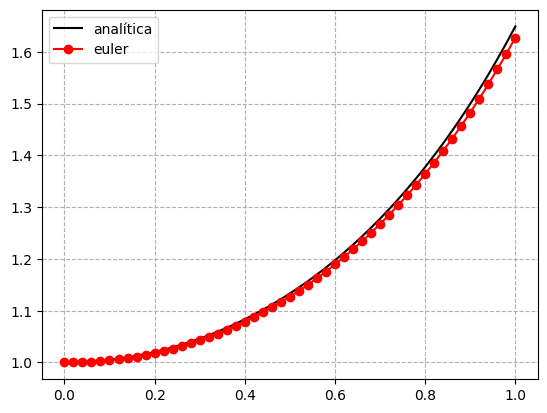

In [2]:
def metodo_euler(f, t0, y0, t_final, h):
    """
    Resolver a EDO pelo método de Euler, para comparação
    f - a EDO que queremos resolver
    t0 - abcissa do ponto inicial
    y0 - ordenada do ponto inicial
    t_final - ordenada do ponto final
    h - passo, precisão de resolução
    """
    X = np.arange(t0, t_final + h, h)
    # Criação de um eixo das abcissas dividido por steps

    Y = np.zeros(len(X))
    # "Cópia" estrutural de do eixo criado

    Y[0] = y0
    # Ponto inicial a partir do qual vamos avaliar o método
    # Ou seja, precisamos de pelo menos um ponto que conhecemos ser uma solução
    
    for i in range(len(X) - 1):
        Y[i+1] = Y[i] + h * f(X[i], Y[i]) 
        # Fazer o contrário de uma derivada
        # Só funciona para EDO's

    return X, Y

def eq_dif(x, y):
    return x * y

def sol_analítica(x, y):
    return np.exp(x**2 / 2)

X = np.arange(0, 1 + 0.02, 0.02)
Y = sol_analítica(X, 0)

plt.plot(X, Y, label="analítica", c="black")

x_euler, y_euler = metodo_euler(eq_dif, 0, 1, 1, 0.02)
plt.plot(x_euler, y_euler, 'ro-', label='euler')
plt.legend()
plt.grid(True, ls="--")
plt.show()


Assumindo todas as massas iguais (escolhe um valor apropriado), todas as molas iguais
(escolhe um valor apropriado) e incluindo molas ligadas a paredes de ambos os lados, simule um
sistema com 5 massas. Como condições iniciais assume que todas as massas se encontram em
repouso e que apenas a massa no centro (m3) se encontra fora da posição de equilíbrio (por um
deslocamento que julgues adequado). Representa graficamente a posição de cada uma das massas
ao longo do tempo (considerar um tempo final que julgues apropriado). Compara as soluções
obtidas pelo método de Euler e pelo método implementado no scipy.integrate

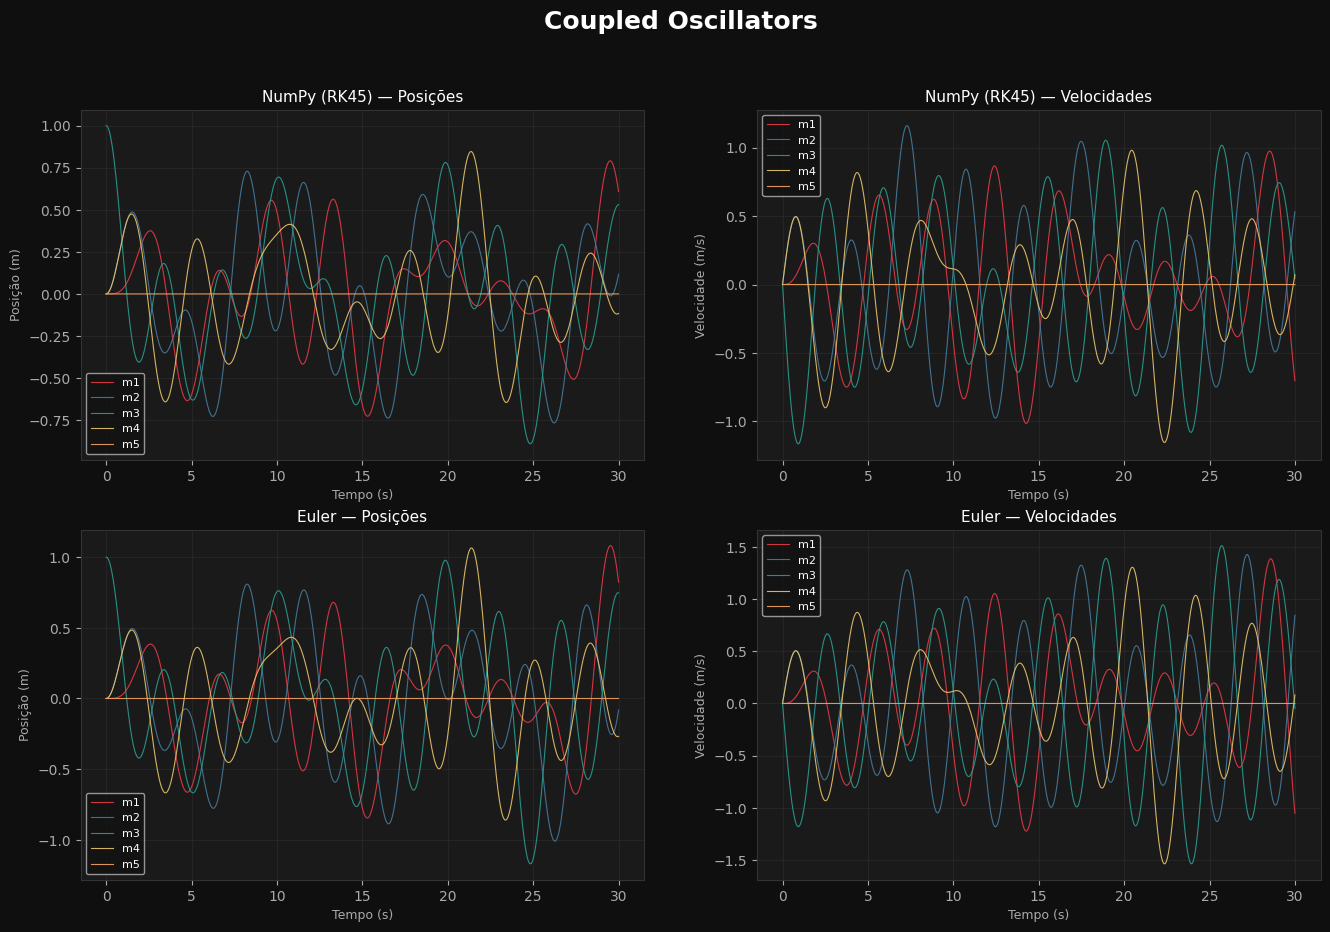

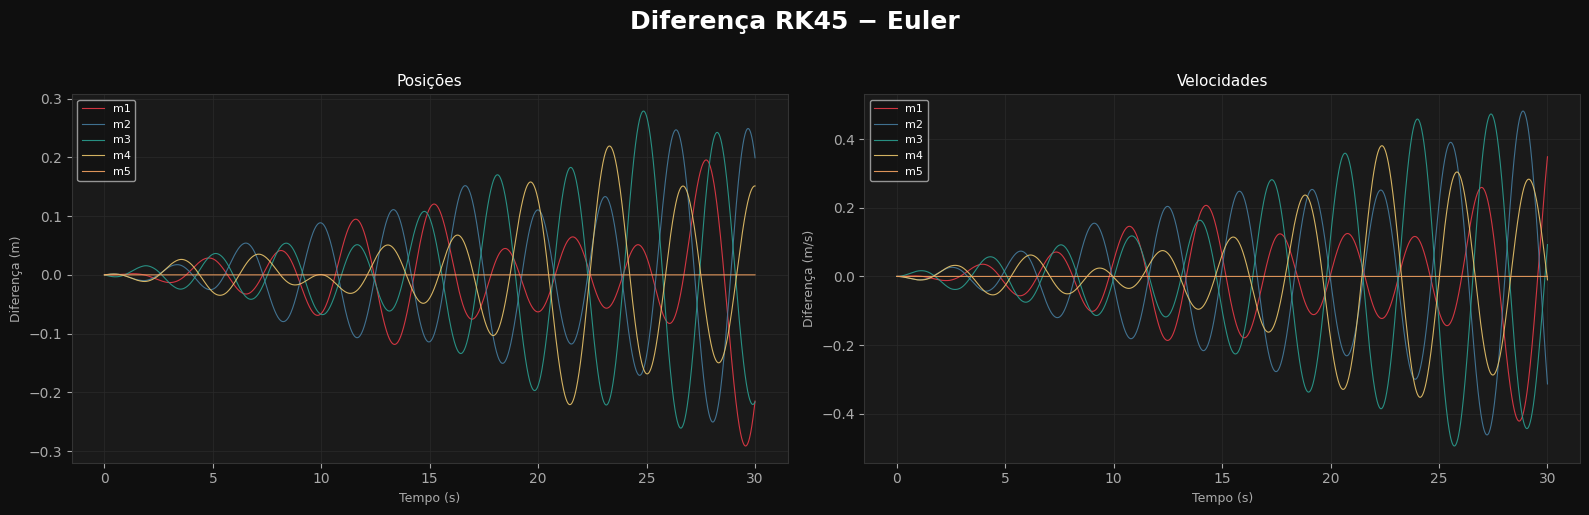

In [3]:
N = 5
m_global = 1
k_global, k_right, k_left = 1, 1, 1
num_points = 3000
t_max = 30
initial_x = [0 for _ in range(N)]
initial_v = np.zeros_like(initial_x)
initial_x[2] = 1

sistema = Coupled_Oscillators(N, m_global, k_global, k_left, k_right)
sol_t_np, sol_u_np, sol_t_euler, sol_u_euler = sistema.solve_coupled_system_linear(initial_x, initial_v, t_max, num_points)

comparison = sol_u_np - sol_u_euler # Onde é que diferem e a partir de quando

# Extrair posições e velocidades
x_np    = sol_u_np[:N, :]
v_np    = sol_u_np[N:, :]
x_euler = sol_u_euler[:N, :]
v_euler = sol_u_euler[N:, :]

colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261']
labels = [f'm{i+1}' for i in range(N)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0f0f0f')
fig.suptitle('Coupled Oscillators', color='white', fontsize=18, fontweight='bold', y=0.98)

titles = [('NumPy (RK45) — Posições', 'Posição (m)'),
          ('NumPy (RK45) — Velocidades', 'Velocidade (m/s)'),
          ('Euler — Posições', 'Posição (m)'),
          ('Euler — Velocidades', 'Velocidade (m/s)')]

data = [(sol_t_np, x_np), (sol_t_np, v_np),
        (sol_t_euler, x_euler), (sol_t_euler, v_euler)]

for ax, (t, y), (title, ylabel) in zip(axes.flat, data, titles):
    ax.set_facecolor('#1a1a1a')
    for i in range(N):
        ax.plot(t, y[i, :], color=colors[i], label=labels[i], linewidth=0.8, alpha=0.9)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Tempo (s)', color='#aaaaaa', fontsize=9)
    ax.set_ylabel(ylabel, color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333333')
    ax.legend(fontsize=8, facecolor='#111111', labelcolor='white', framealpha=0.7)
    ax.grid(True, color='#2a2a2a', linewidth=0.5)


x_diff = comparison[:N, :]
v_diff = comparison[N:, :]

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f0f0f')
fig2.suptitle('Diferença RK45 − Euler', color='white', fontsize=18, fontweight='bold', y=1.02)

data_diff  = [(sol_t_np, x_diff, 'Posições', 'Diferença (m)'),
              (sol_t_np, v_diff, 'Velocidades', 'Diferença (m/s)')]

for ax, (t, y, title, ylabel) in zip(axes2.flat, data_diff):
    ax.set_facecolor('#1a1a1a')
    for i in range(N):
        ax.plot(t, y[i, :], color=colors[i], label=labels[i], linewidth=0.8, alpha=0.9)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Tempo (s)', color='#aaaaaa', fontsize=9)
    ax.set_ylabel(ylabel, color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333333')
    ax.legend(fontsize=8, facecolor='#111111', labelcolor='white', framealpha=0.7)
    ax.grid(True, color='#2a2a2a', linewidth=0.5)


plt.tight_layout()
plt.show()

Repete a simulação com condições iniciais em que as massas estão todas em repouso, mas
em que estão todas deslocadas pela mesma distância para um lado. Existe alguma diferença com os resultados da alínea anterior? Comenta

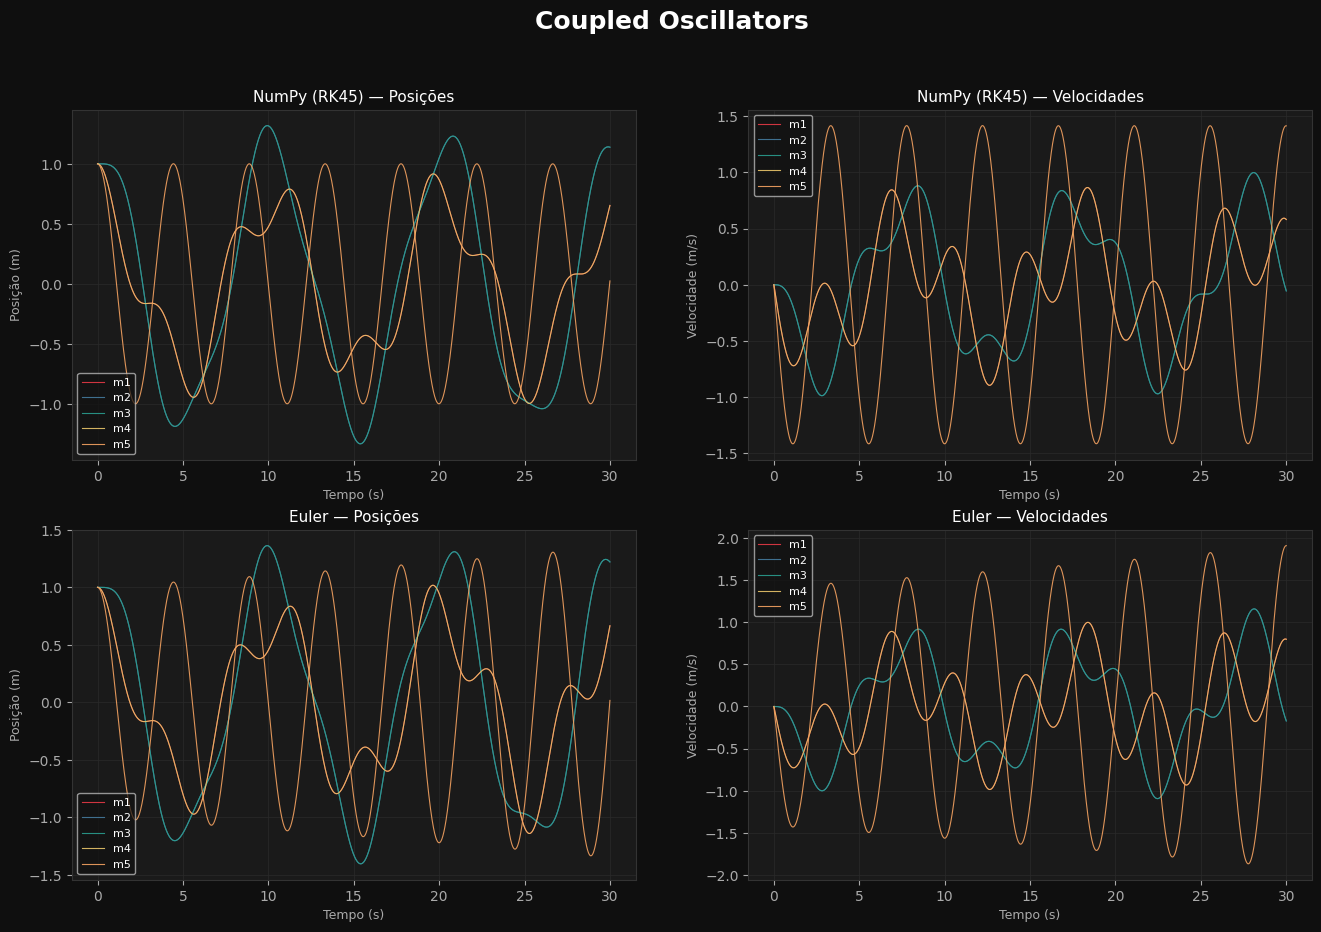

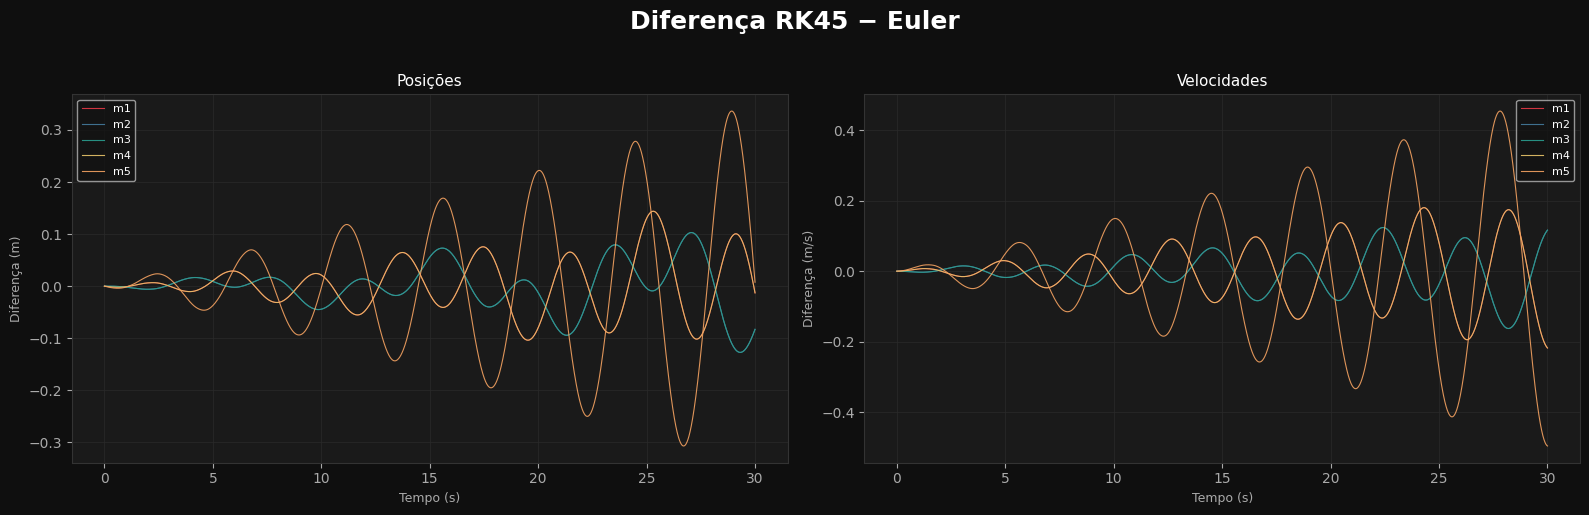

In [4]:
N = 5
m_global = 1
k_global, k_right, k_left = 1, 1, 1
num_points = 3000
t_max = 30
initial_x = [1 for _ in range(N)]
initial_v = np.zeros_like(initial_x)

sistema = Coupled_Oscillators(N, m_global, k_global, k_left, k_right)
sol_t_np, sol_u_np, sol_t_euler, sol_u_euler = sistema.solve_coupled_system_linear(initial_x, initial_v, t_max, num_points)

comparison = sol_u_np - sol_u_euler # Onde é que diferem e a partir de quando

# Extrair posições e velocidades
x_np    = sol_u_np[:N, :]
v_np    = sol_u_np[N:, :]
x_euler = sol_u_euler[:N, :]
v_euler = sol_u_euler[N:, :]



colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261']
labels = [f'm{i+1}' for i in range(N)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0f0f0f')
fig.suptitle('Coupled Oscillators', color='white', fontsize=18, fontweight='bold', y=0.98)

titles = [('NumPy (RK45) — Posições', 'Posição (m)'),
          ('NumPy (RK45) — Velocidades', 'Velocidade (m/s)'),
          ('Euler — Posições', 'Posição (m)'),
          ('Euler — Velocidades', 'Velocidade (m/s)')]

data = [(sol_t_np, x_np), (sol_t_np, v_np),
        (sol_t_euler, x_euler), (sol_t_euler, v_euler)]

for ax, (t, y), (title, ylabel) in zip(axes.flat, data, titles):
    ax.set_facecolor('#1a1a1a')
    for i in range(N):
        ax.plot(t, y[i, :], color=colors[i], label=labels[i], linewidth=0.8, alpha=0.9)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Tempo (s)', color='#aaaaaa', fontsize=9)
    ax.set_ylabel(ylabel, color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333333')
    ax.legend(fontsize=8, facecolor='#111111', labelcolor='white', framealpha=0.7)
    ax.grid(True, color='#2a2a2a', linewidth=0.5)


x_diff = comparison[:N, :]
v_diff = comparison[N:, :]

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 5), facecolor='#0f0f0f')
fig2.suptitle('Diferença RK45 − Euler', color='white', fontsize=18, fontweight='bold', y=1.02)

data_diff  = [(sol_t_np, x_diff, 'Posições', 'Diferença (m)'),
              (sol_t_np, v_diff, 'Velocidades', 'Diferença (m/s)')]

for ax, (t, y, title, ylabel) in zip(axes2.flat, data_diff):
    ax.set_facecolor('#1a1a1a')
    for i in range(N):
        ax.plot(t, y[i, :], color=colors[i], label=labels[i], linewidth=0.8, alpha=0.9)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Tempo (s)', color='#aaaaaa', fontsize=9)
    ax.set_ylabel(ylabel, color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333333')
    ax.legend(fontsize=8, facecolor='#111111', labelcolor='white', framealpha=0.7)
    ax.grid(True, color='#2a2a2a', linewidth=0.5)


plt.tight_layout()
plt.show()

A energia cinética é dada por:
$$T(t) = \frac{1}{2}\sum^{N}_{i=1}m_i \dot{x}_i^2(t) = \frac{1}{2}\bold{v}^T(t)\bold{M}\bold{v}(t)$$
A energia potencial é dada por:
$$V(t) = \frac{1}{2}k_L\dot{x}_1^2(t)+\frac{1}{2}\sum_{i=1}^{N-1}k_{i,i+1}(x_{i+1}(t)-x_i(t))^2 + \frac{1}{2}k_R x_N^2(t) = \frac{1}{2}\bold{x}^T(t)\bold{Kx}(t)$$

Represente graficamente a evoluçaõ no tempo da energia cinética $T$, da energia potencial $V$, e da energia mecânica total $E = T + V$. Sabendo que a energia total é conservada, compare a precisão dos dois métodos usados para reslver as equaç~çoes diferenciais. 
Em princípio o método que conserva melhor a energia mecância total será o que tem mais precisão.

Vamos aplicá-lo à simulação corrida anteriormente.

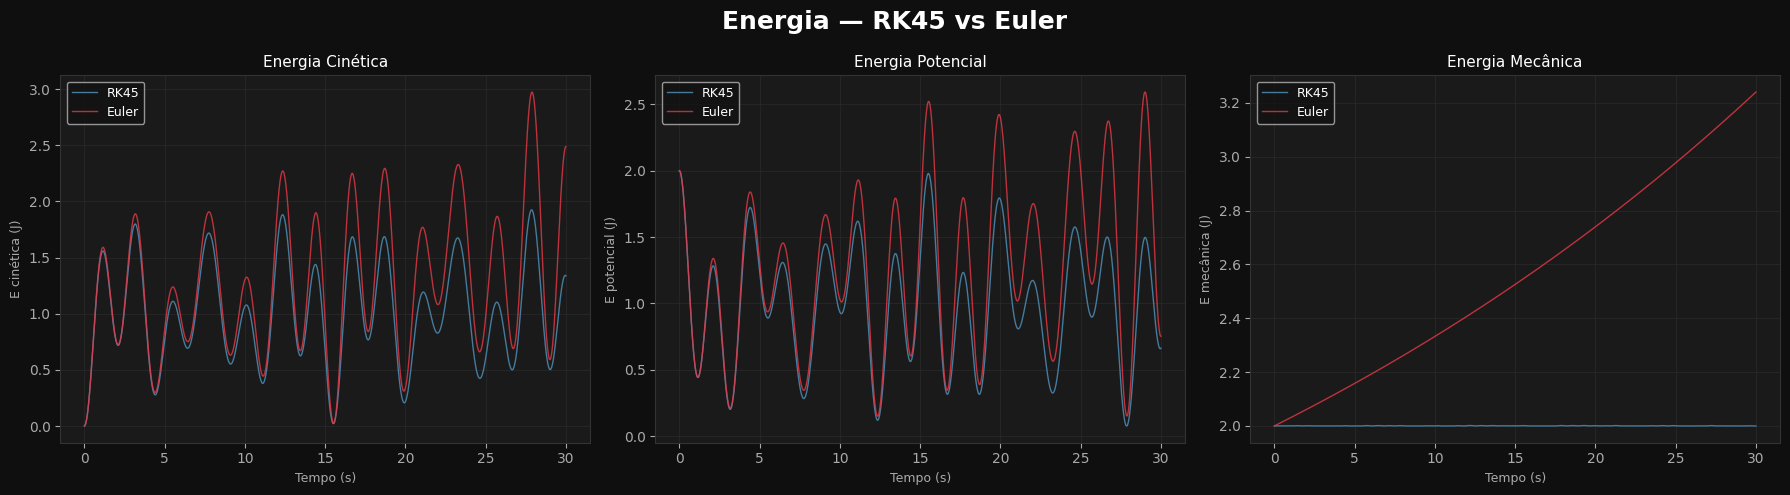

In [9]:
def kinetic(vel, M):
    num_points = vel.shape[1] # retorna um tuplo de dimensões da matriz
    kin = np.zeros(num_points) # Queremos a energia cinética total sistema 
    for i in range(num_points):
        kin[i] = 0.5 * (vel[:, i] @ M @ vel[:, i]) # [:, i] dá a coluna i, ou seja, um snapshot no instante i.
    return kin

def potencial(pos, K):
    num_points = pos.shape[1]
    pot = np.zeros(num_points)
    for i in range(num_points):
        pot[i] = 0.5 * (pos[:, i] @ K @ pos[:, i])
    return pot

np_potencial = potencial(x_np, sistema.K)
np_kinetic = kinetic(v_np, sistema.M)
np_mec = np_potencial + np_kinetic

euler_potencial = potencial(x_euler, sistema.K)
euler_kinetic = kinetic(v_euler, sistema.M)
euler_mec = euler_potencial + euler_kinetic

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f0f0f')
fig3.suptitle('Energia — RK45 vs Euler', color='white', fontsize=18, fontweight='bold')

energy_data = [
    (np_kinetic,   euler_kinetic,   'Energia Cinética',   'E cinética (J)'),
    (np_potencial, euler_potencial, 'Energia Potencial',  'E potencial (J)'),
    (np_mec,       euler_mec,       'Energia Mecânica',   'E mecânica (J)'),
]

for ax, (e_np, e_euler, title, ylabel) in zip(axes3, energy_data):
    ax.set_facecolor('#1a1a1a')
    ax.plot(sol_t_np, e_np,    color='#457b9d', label='RK45',  linewidth=1.0)
    ax.plot(sol_t_np, e_euler, color='#e63946', label='Euler', linewidth=1.0, alpha=0.8)
    ax.set_title(title, color='white', fontsize=11)
    ax.set_xlabel('Tempo (s)', color='#aaaaaa', fontsize=9)
    ax.set_ylabel(ylabel, color='#aaaaaa', fontsize=9)
    ax.tick_params(colors='#aaaaaa')
    ax.spines[:].set_color('#333333')
    ax.legend(fontsize=9, facecolor='#111111', labelcolor='white', framealpha=0.7)
    ax.grid(True, color='#2a2a2a', linewidth=0.5)

plt.tight_layout()
plt.show()

